In [ ]:
# Step A: Connect Colab to your Google Drive account
from google.colab import drive
drive.mount('/content/drive')

# Step B: Point Python directly to the 'Data' subfolder where your files live
import os
os.chdir('/content/drive/MyDrive/AI_Tool_Adoption_Analysis_Project/Data')

# Step C: Read the dataset file sitting next to this notebook
import pandas as pd
df = pd.read_csv("AI_Adoption_Research_Grade_350.csv")

# Step D: Display the first 5 rows of your data to confirm it works
df.head()

Mounted at /content/drive


,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,AI_Adoption_Score,Monthly_AI_Users,Productivity_Gain_Percent,Satisfaction_Score,AI_Investment_USD,Annual_Cost_Savings_USD,ROI_Percent,Training_Hours_Per_Employee,Automation_Level_Percent
0,ORG0001,Manufacturing,Medium,522,Claude,2025,76,206,50.31,7.6,48016.29,93254.21,94.21,30,80
1,ORG0002,Manufacturing,Small,116,Cursor,2021,56,27,31.51,2.5,24307.60,59121.97,143.22,53,48
2,ORG0003,Finance,Medium,380,GitHub Copilot,2023,84,100,39.27,4.3,68441.93,137213.19,100.48,15,91
3,ORG0004,Retail,Small,35,Cursor,2024,61,14,32.68,4.3,7718.52,13394.36,73.54,80,68
4,ORG0005,Marketing,Small,121,Gemini,2024,78,25,53.08,7.4,18492.33,32151.76,73.87,54,85


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv("AI_Adoption_Research_Grade_350.csv")

# Display first 5 rows
df.head()

print("Number of Rows and Columns:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)

#it shows data types
print(df.info())

#check missing values
print("Missing Values:")
print(df.isnull().sum())

#check duplicates
duplicates = df.duplicated().sum()
print("Number of Duplicate Records:")
print(duplicates)

#statistical summary
df.describe()

Number of Rows and Columns:
(350, 15)

Column Names:
Index(['Organization_ID', 'Industry', 'Company_Size', 'Employee_Count',
       'AI_Tool', 'Adoption_Year', 'AI_Adoption_Score', 'Monthly_AI_Users',
       'Productivity_Gain_Percent', 'Satisfaction_Score', 'AI_Investment_USD',
       'Annual_Cost_Savings_USD', 'ROI_Percent', 'Training_Hours_Per_Employee',
       'Automation_Level_Percent'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Organization_ID              350 non-null    object 
 1   Industry                     350 non-null    object 
 2   Company_Size                 350 non-null    object 
 3   Employee_Count               350 non-null    int64  
 4   AI_Tool                      350 non-null    object 
 5   Adoption_Year                350 non-null    int64  
 6   AI_Adopt

,Employee_Count,Adoption_Year,AI_Adoption_Score,Monthly_AI_Users,Productivity_Gain_Percent,Satisfaction_Score,AI_Investment_USD,Annual_Cost_Savings_USD,ROI_Percent,Training_Hours_Per_Employee,Automation_Level_Percent
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000,3.500000e+02,3.500000e+02,350.000000,350.000000,350.000000
mean,1622.011429,2023.200000,77.194286,669.865714,44.021343,5.435714,3.349307e+05,7.455022e+05,117.788486,54.571429,76.354286
std,2549.685288,1.883422,13.967296,1154.849375,11.927020,1.736713,5.889359e+05,1.382111e+06,60.206821,27.579306,16.338650
min,20.000000,2019.000000,41.000000,7.000000,18.700000,1.400000,2.121720e+03,3.746670e+03,10.010000,5.000000,29.000000
25%,164.000000,2022.000000,68.000000,58.000000,35.065000,4.300000,3.394340e+04,6.551585e+04,68.977500,31.000000,65.250000
50%,495.000000,2023.500000,79.000000,166.500000,44.535000,5.550000,8.191386e+04,1.870293e+05,116.125000,54.000000,78.000000
75%,983.000000,2025.000000,88.000000,490.000000,52.795000,6.600000,2.615502e+05,5.145815e+05,172.392500,78.000000,90.000000
max,9994.000000,2026.000000,100.000000,5801.000000,73.140000,9.800000,3.150534e+06,8.412984e+06,219.770000,99.000000,100.000000


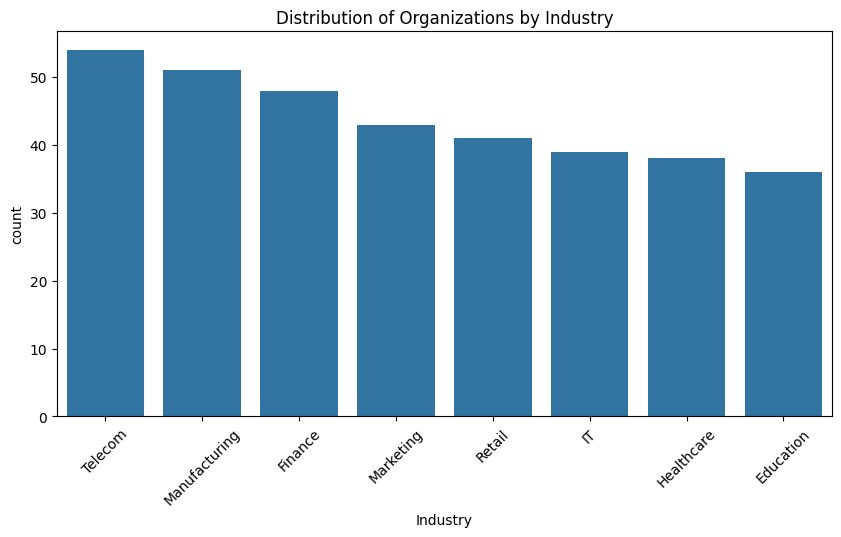

In [ ]:
#industry distribution
plt.figure(figsize=(10,5))
sns.countplot(
    x='Industry',
    data=df,
    order=df['Industry'].value_counts().index
)
plt.title("Distribution of Organizations by Industry")
plt.xticks(rotation=45)
plt.show()


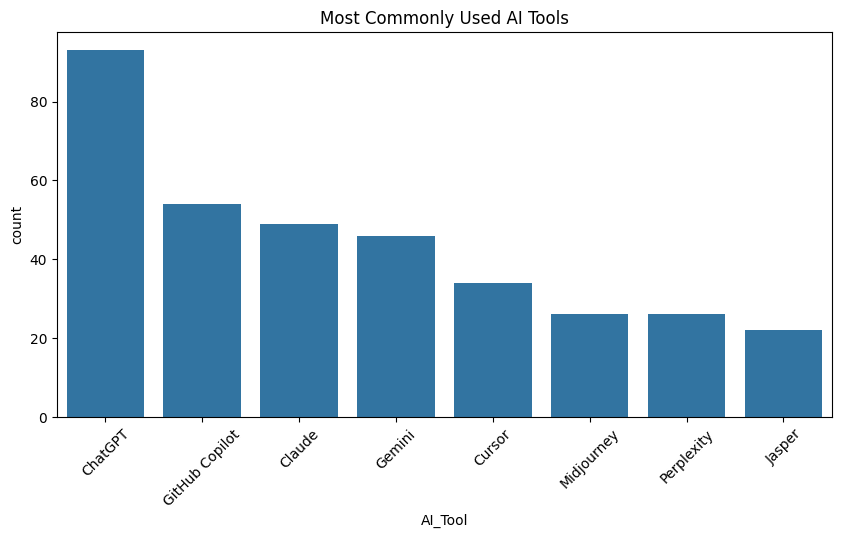

In [ ]:
#AI tool usage distribution
plt.figure(figsize=(10,5))
sns.countplot(
    x='AI_Tool',
    data=df,
    order=df['AI_Tool'].value_counts().index
)
plt.title("Most Commonly Used AI Tools")
plt.xticks(rotation=45)
plt.show()

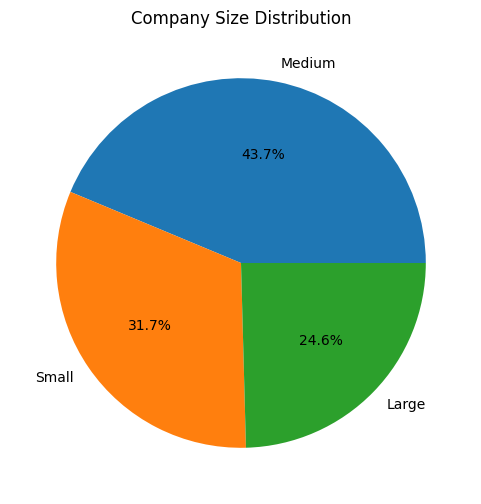

In [ ]:
# company size distribution
plt.figure(figsize=(6,6))
df['Company_Size'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title("Company Size Distribution")
plt.show()

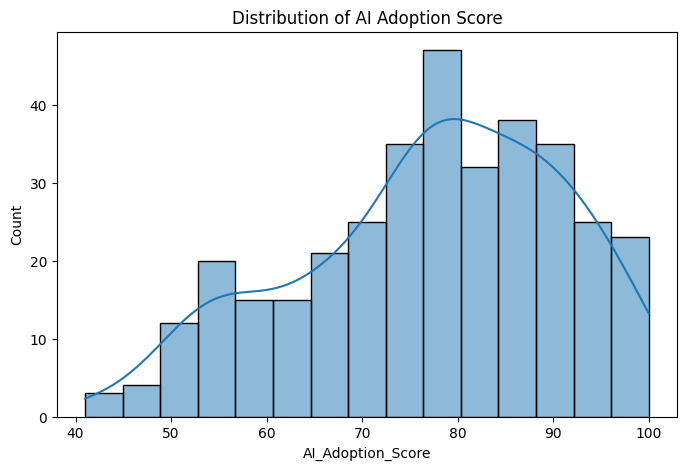

In [ ]:
#AI adoption score distibution
plt.figure(figsize=(8,5))
sns.histplot(
    df['AI_Adoption_Score'],
    bins=15,
    kde=True
)
plt.title("Distribution of AI Adoption Score")
plt.show()

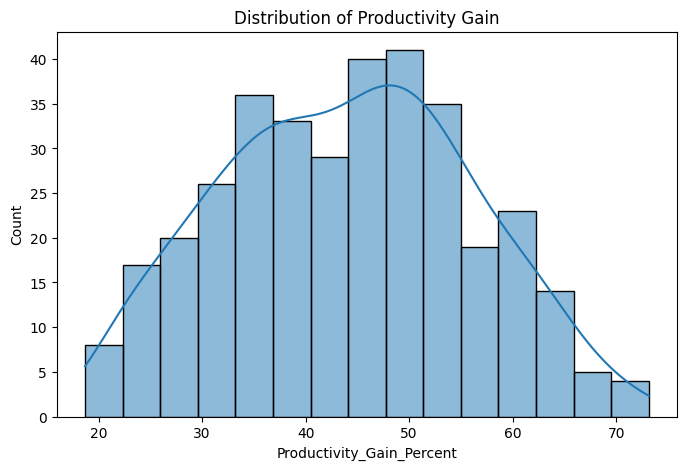

In [ ]:
#productivity gain distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df['Productivity_Gain_Percent'],
    bins=15,
    kde=True
)
plt.title("Distribution of Productivity Gain")
plt.show()

In [ ]:
#common AI tools
print(df['AI_Tool'].value_counts())

#industry-wise adoption
industry_adoption = df.groupby('Industry')['AI_Adoption_Score'].mean()
print(industry_adoption.sort_values(ascending=False))

AI_Tool
ChatGPT           93
GitHub Copilot    54
Claude            49
Gemini            46
Cursor            34
Midjourney        26
Perplexity        26
Jasper            22
Name: count, dtype: int64
Industry
IT               91.179487
Finance          87.208333
Telecom          84.703704
Healthcare       80.605263
Marketing        75.232558
Retail           70.756098
Education        66.305556
Manufacturing    61.098039
Name: AI_Adoption_Score, dtype: float64


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
# 1. Stage the newly cleaned notebook
!git add Data_Description_1.ipynb

# 2. Make a new commit overwriting the previous one
!git commit -m "Removed exposed personal access token"

# 3. Push it up again
!git push https://github.com/Abirami-MJ/AI_Tool_Adoption_Analysis_Project.git master:main -f

[master ef64959] Removed exposed personal access token
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 747.83 KiB | 5.71 MiB/s, done.
Total 12 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), done.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   —————————————————————————————————————————
remote:     Resolve the following violations before pushing again
remote: 
remote:     - Push cannot contain secrets
remote: 
remote:     
remote:      (?) Learn how to resolve a blocked push
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push
remote:     
remote:     
remote: 